# <p align = "center"> Clustering Analysis of RMSD </p>

<details open>
<summary> <strong> <ins> Key Points </ins> </strong> </summary>

- Labels-aware

    - Ligand Labels

        - Visual Identification

- Labels-agnostic

</details>


In [2]:
# Load Key Libraries
from pathlib import Path
rootdir = Path("../../../..").resolve()
import sys
sys.path.insert(0, str(rootdir) )
from typing import Callable, Generator

import gemmi 
import parasail
import numpy as np
from rdkit import Chem
import matplotlib.pyplot as plt

from xaidar.data.molecModels import loadPDB
from xaidar.data.molecModels import get_pdb_stats, sele_pdb, sele_Lig, get_res_CoM
from xaidar.data.molecModels import flatten_pdb, sele_AA, createPDB, get_atom_coord

/home/eoo22534/mydir/xaidar/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load rmsd matrix

In [4]:
saveDir = rootdir.joinpath("data/ev2a/fragalysis/03-calcs/ca_rmsd.npy")
ca_rmsd_matrix = np.load( saveDir )
print( "ca_rmsd_matrix shape: ",ca_rmsd_matrix.shape )

import pickle as pkl

with open( rootdir.joinpath("data/ev2a/fragalysis/03-calcs/ca_rmsd_id2set_map.pkl"), "rb" ) as file:
    ca_rmsd_id2set_map = pkl.load( file )
    _, lst_matrix_datasets = zip( *ca_rmsd_id2set_map)
    del _
print("\nca_rmsd_id2set_map Content: ", "\n\t",
        ca_rmsd_id2set_map[:10]
)
print( "\nlst_all_datasets: ", "\n\t",
      lst_matrix_datasets[:10])

with open( rootdir.joinpath("data/ev2a/fragalysis/03-calcs/ca_rmsd_set2id_map.pkl"), "rb" ) as file:
    ca_rmsd_set2id_map = pkl.load( file )
print("\nca_rmsd_set2id_map Keys and Subkeys and values: ", "\n\t",
       ca_rmsd_set2id_map.keys(), "\n\t", 
       list(ca_rmsd_set2id_map["piperidine"].keys())[:10],"\n\t",  
       list(ca_rmsd_set2id_map["piperidine"].values())[:10]  )

ca_rmsd_matrix shape:  (467, 467)

ca_rmsd_id2set_map Content:  
	 [('fragscreen', 'A0451a'), ('fragscreen', 'A0365a'), ('fragscreen', 'A1255a'), ('fragscreen', 'A0310a'), ('fragscreen', 'A1180a'), ('fragscreen', 'A0514a'), ('fragscreen', 'A1148a'), ('fragscreen', 'A1169a'), ('fragscreen', 'A0884a'), ('fragscreen', 'A0526a')]

lst_all_datasets:  
	 ('A0451a', 'A0365a', 'A1255a', 'A0310a', 'A1180a', 'A0514a', 'A1148a', 'A1169a', 'A0884a', 'A0526a')

ca_rmsd_set2id_map Keys and Subkeys and values:  
	 dict_keys(['fragscreen', 'nonactivesite', 'piperidine']) 
	 ['A0926a', 'A3054a', 'A3186a', 'A3188a', 'A3189a', 'A3191a', 'A3193a', 'A3194a', 'A3207a', 'A3208a'] 
	 [120, 121, 122, 123, 124, 125, 126, 127, 128, 129]


## Perform Spectral Clustering

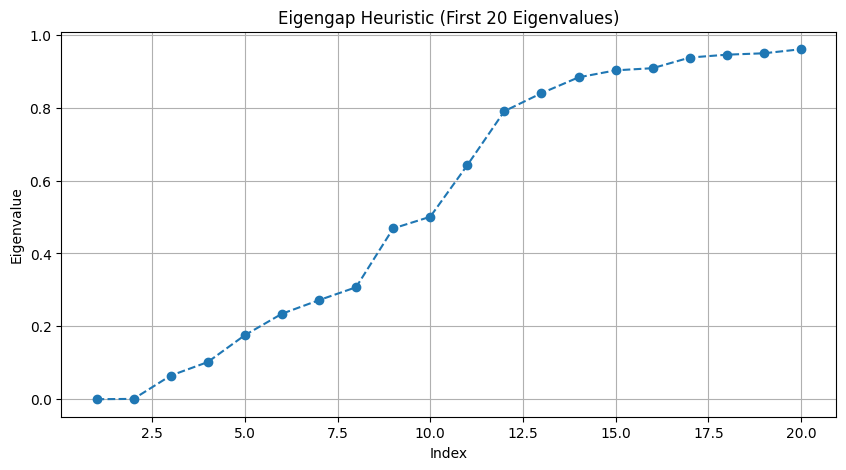

The suggested number of clusters is: 8


In [ ]:
# Performing Clustering and Extracting the Matrix Index of Each Protein Associated to each Cluster Label -> spec_cluster_labels[ n_clusters][ clust_label (e.g. 0,1,...) ][ idxs | datasets | manual]
from sklearn.cluster import SpectralClustering
from collections import defaultdict
from scipy.sparse.csgraph import laplacian
from scipy.linalg import eigh
# spectral clustering on rmsd matrix

# 3. Convert Distance Matrix to an Affinity (Similarity) Matrix
# Spectral clustering needs high values for similar items, and low values for dissimilar items.
# We use a Gaussian (RBF) kernel conversion: exp(-gamma * distance^2)

# A common heuristic for gamma is 1 / variance of the distances
gamma = 1.0 / np.var(ca_rmsd_matrix)
affinity_matrix = np.exp(-gamma * ca_rmsd_matrix**2)

# Compute Normalized Laplacian in one line
# 'normed=True' computes L_sym = I - D^-1/2 A D^-1/2
L = laplacian(affinity_matrix, normed=True)

# 4. Solve for Eigenvalues
# Since L is symmetric, eigh is faster and more accurate than eig
eigenvalues, vecs = eigh(L)

# 5. Plot the Eigengap to identify the number of clusters
plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), eigenvalues[:20], marker='o', linestyle='--')
plt.title('Eigengap Heuristic (First 20 Eigenvalues)')
plt.xlabel('Index')
plt.ylabel('Eigenvalue')
plt.grid(True)
plt.show()

# The "Ideal K" is the index before the largest gap
gaps = np.diff(eigenvalues[:20])
k_ideal = np.argmax(gaps) + 1
print(f"The suggested number of clusters is: {k_ideal}")


In [ ]:
clustering = SpectralClustering(n_clusters=k_ideal,                      # Perform Spectral Clustering
                        affinity='precomputed', assign_labels='kmeans')
clust_proj_labels = clustering.fit_predict( affinity_matrix )  

labels_dict = { }                                                           # Save cluster labels for each cluster project / campaign
for target_clst_label in set( clust_proj_labels):
    labels_dict[int(target_clst_label)] = {"idxs" : 
        [idx for idx,  clust_label in enumerate( clust_proj_labels )
        if int(clust_label) == int(target_clst_label) ] }                   # Add the indice of the proteins in the rmsd matrix that match each specific cluster label
    
ordered_labels_dict = dict( sorted(labels_dict.items(),                     # Order Based off of the size of the cluster
                key = lambda item: len(item[1]["idxs"]), reverse = True) )  
ordered_labels_dict = { idx : content                                       # Change Labels to Match the size order
            for idx, content in enumerate(ordered_labels_dict.values())}

---

In [7]:

spec_cluster_labels = dict() #  []                                              # Initiate final Save Object of all the labels. 
for n_clusters in range(8,9): #      (2, 20):  #                                           # For Each cluster project / campaign (with a specific set # of clusters)
    clustering = SpectralClustering(n_clusters=n_clusters,                      # Perform Spectral Clustering
                            affinity='precomputed', assign_labels='kmeans')
    clust_proj_labels = clustering.fit_predict( affinity_matrix )               # Get cluster label of each dataset into a list
                
    labels_dict = { }                                                           # Save cluster labels for each cluster project / campaign
    for target_clst_label in set( clust_proj_labels):
        labels_dict[int(target_clst_label)] = {"idxs" : 
            [idx for idx,  clust_label in enumerate( clust_proj_labels )
            if int(clust_label) == int(target_clst_label) ] }                   # Add the indice of the proteins in the rmsd matrix that match each specific cluster label
        
    ordered_labels_dict = dict( sorted(labels_dict.items(),                     # Order Based off of the size of the cluster
                    key = lambda item: len(item[1]["idxs"]), reverse = True) )  
    ordered_labels_dict = { idx : content                                       # Change Labels to Match the size order
                for idx, content in enumerate(ordered_labels_dict.values())}
    spec_cluster_labels[int(n_clusters)] = ordered_labels_dict                  

print( "Format of Cluster Save Object: dict( dict( dict( list ) ) ) ")
print( "\tspec_cluster_labels[ n_clusters][ clust_label (e.g. 0,1,...) ][ idxs | datasets | manual_label] : value ")

Format of Cluster Save Object: dict( dict( dict( list ) ) ) 
	spec_cluster_labels[ n_clusters][ clust_label (e.g. 0,1,...) ][ idxs | datasets | manual_label] : value 


In [11]:
# Looking at initial Resulting Dictionary -> spec_cluster_labels
clst_proj, label = 8, 3
print(f"Example of Resulting Linked Dictionary For Clustering with {clst_proj} Clusters")
print( f"\tDictionary keys for a specific cluster label ({label}):", spec_cluster_labels[clst_proj][label].keys() )
print( f"\tExample Idxs for Cluster Label {label}:\t\t", spec_cluster_labels[clst_proj][label]["idxs"] )
print("Cluster Labels By Size Order")
print("\t(Label, Size) : ",  *[ (cluster_label, len(lst_indexes["idxs"] )) for cluster_label, lst_indexes in spec_cluster_labels[clst_proj].items()])


Example of Resulting Linked Dictionary For Clustering with 8 Clusters
	Dictionary keys for a specific cluster label (3): dict_keys(['idxs', 'datasets'])
	Example Idxs for Cluster Label 3:		 [25, 32, 57, 119]
Cluster Labels By Size Order
	(Label, Size) :  (0, 392) (1, 58) (2, 4) (3, 4) (4, 3) (5, 2) (6, 2) (7, 2)


In [15]:
# Link the Protein Dataset IDs to the Cluster Labels throught the matrix indices 
for clust_size, clust_dict in spec_cluster_labels.items() :
    for clust_label, clust_label_dict in clust_dict.items():
            clust_label_dict["datasets"] = [ lst_matrix_datasets[idx] 
                                        for idx in clust_label_dict["idxs"] ] 

In [16]:
# Looking into resulting Dataset ID 2 Cluster Label Dictionary
print("Example of Resulting Linked Dictionary")
print( "\tDictionary keys for a specific cluster label (1):", 
                spec_cluster_labels[8][1].keys() )
print( "\tExample Datasets for Cluster Label 1:\t\t", 
                spec_cluster_labels[8][1]["datasets"] )
print( "\tExample Idxs for Cluster Label 1:\t\t", 
                spec_cluster_labels[8][1]["idxs"] )


Example of Resulting Linked Dictionary
	Dictionary keys for a specific cluster label (1): dict_keys(['idxs', 'datasets'])
	Example Datasets for Cluster Label 1:		 ['A0451a', 'A1255a', 'A1180a', 'A0526a', 'A0566a', 'A0416a', 'A0556a', 'A0443a', 'A1292a', 'A0473a', 'A0501b', 'A0375b', 'A1019a', 'A0739a', 'A0732a', 'A0446a', 'A1209a', 'A0428a', 'A0375a', 'A0853a', 'A0229b', 'A0305a', 'A1145b', 'A0691a', 'A0831a', 'A0469a', 'A0152b', 'A0608a', 'A0202a', 'A0332a', 'A0571a', 'A0309a', 'A0412a', 'A1068c', 'A0396a', 'A0486a', 'A1084a', 'A2448a', 'A0359a', 'A0228a', 'A0541a', 'A1128a', 'A0517a', 'A1293a', 'A0278b', 'A0540a', 'A0239a', 'A2458a', 'A1081a', 'A0333a', 'A0354a', 'A0525a', 'A0488a', 'A0269a', 'A0194a', 'A0188a', 'A0341a', 'A0922a']
	Example Idxs for Cluster Label 1:		 [0, 2, 4, 9, 12, 14, 16, 17, 21, 22, 26, 27, 30, 31, 37, 38, 39, 41, 45, 47, 49, 51, 54, 55, 58, 59, 61, 62, 63, 65, 66, 71, 72, 73, 74, 80, 84, 85, 87, 89, 90, 91, 92, 99, 100, 102, 103, 104, 105, 107, 108, 109, 110, 1

## Ligands Manual Clustering


<details open>
<summary> <font size="5"> <ins> Pymol Processing </ins> </font> </summary>



- Load all the ligands from `01-concatdir/aligned_files/{datasetcode}_ligand.pdb`

- Get centre of mass for one ligand

- Select ligands within 2 $\AA$ radius

    `select ligs, bymolecule (resn LIG within 2  of sele)`

- Visually inspect, deselect or add ligands accordingly

- Get name of ligands

    `print( cmd.get_names("objects", selection = "sele") )`

- Clear and repeat

    `deselect`

</details>

- ### <ins> Manual Clustering Result</ins>

<img src="../../../../images/clusters/clusters.png" width = 20%>

Note:

- The distinction betweeen cluster 6 and 7 is quite faint and arbitrary

- ### <ins> Saving Manual Clustering Results in a Python Object </ins>

In [17]:
# Initialise Manual Clustering Save Object -> `manual_cluster_dict`
manual_cluster_dict = {val : [] for val in range( 1, 11 ) }
print(manual_cluster_dict)

{1: [], 2: [], 3: [], 4: [], 5: [], 6: [], 7: [], 8: [], 9: [], 10: []}


In [18]:
# Add nonpiperidine clusters to save object

# First, create a list and copy output from PyMol into it
nonpip_cluster_lists= [
['A0571a_ligand', 'A0517a_ligand'],
['A3181b_ligand', 'A4596b_ligand', 'A1145a_ligand', 'A0528b_ligand', 'A0900a_ligand', 'A0863a_ligand', 'A1146a_ligand', 'A1128a_ligand', 'A0514b_ligand', 'A0333a_ligand', 'A0351b_ligand', 'A0719b_ligand'],
['A0229a_ligand', 'A0469a_ligand', 'A0152a_ligand', 'A0359a_ligand', 'A0228a_ligand', 'A0278a_ligand', 'A0540a_ligand', 'A0525a_ligand'],
['A0608a_ligand', 'A0309a_ligand', 'A0486a_ligand', 'A0239a_ligand'],
['A0428a_ligand', 'A0586a_ligand', 'A0305a_ligand', 'A0691a_ligand', 'A0332a_ligand', 'A2448a_ligand', 'A0541a_ligand', 'A2458a_ligand', 'A0278b_ligand', 'A0229b_ligand', 'A0354a_ligand', 'A0717a_ligand', 'A0188a_ligand'],
['A0375c_ligand', 'A1148b_ligand', 'A1109a_ligand', 'A0875b_ligand', 'A0395a_ligand', 'A0351c_ligand', 'A1105a_ligand'],
['A0497a_ligand', 'A3550b_ligand', 'A0515b_ligand', 'A0202a_ligand', 'A1105b_ligand', 'A1293a_ligand', 'A3977b_ligand', 'A0395b_ligand', 'A0152b_ligand', 'A0269a_ligand', 'A0194a_ligand', 'A0341a_ligand'],
['A0202b_ligand', 'A1084a_ligand', 'A0488a_ligand'],
]

print("Cluster ID : # Ligands")
for idx, lst in enumerate(nonpip_cluster_lists):
    print( f"  Cluster {idx+1}: {len(lst)}")

# Remove "_ligand" from names
nonpip_cluster_lists = [ [dataset[:-7] for dataset in clust_lst ] for clust_lst in nonpip_cluster_lists ]

# Add dataset codes into the save Object
for val in list(manual_cluster_dict.keys())[:len(nonpip_cluster_lists)]: manual_cluster_dict[val] = nonpip_cluster_lists[val-1]

print("")
print("Resulting Save Obj with added non-piperidine Ligands:")
print("\t", manual_cluster_dict)

    

Cluster ID : # Ligands
  Cluster 1: 2
  Cluster 2: 12
  Cluster 3: 8
  Cluster 4: 4
  Cluster 5: 13
  Cluster 6: 7
  Cluster 7: 12
  Cluster 8: 3

Resulting Save Obj with added non-piperidine Ligands:
	 {1: ['A0571a', 'A0517a'], 2: ['A3181b', 'A4596b', 'A1145a', 'A0528b', 'A0900a', 'A0863a', 'A1146a', 'A1128a', 'A0514b', 'A0333a', 'A0351b', 'A0719b'], 3: ['A0229a', 'A0469a', 'A0152a', 'A0359a', 'A0228a', 'A0278a', 'A0540a', 'A0525a'], 4: ['A0608a', 'A0309a', 'A0486a', 'A0239a'], 5: ['A0428a', 'A0586a', 'A0305a', 'A0691a', 'A0332a', 'A2448a', 'A0541a', 'A2458a', 'A0278b', 'A0229b', 'A0354a', 'A0717a', 'A0188a'], 6: ['A0375c', 'A1148b', 'A1109a', 'A0875b', 'A0395a', 'A0351c', 'A1105a'], 7: ['A0497a', 'A3550b', 'A0515b', 'A0202a', 'A1105b', 'A1293a', 'A3977b', 'A0395b', 'A0152b', 'A0269a', 'A0194a', 'A0341a'], 8: ['A0202b', 'A1084a', 'A0488a'], 9: [], 10: []}


In [19]:
# Add piperidine clusters to save object

# First, create a list and copy output from PyMol into it
pip_cluster_lists = [
['A7175a_ligand', 'A5039b_ligand', 'A5460a_ligand', 'A3181a_ligand', 'A0451a_ligand', 'A4035b_ligand', 'A5424a_ligand', 'A4035a_ligand', 'A5247b_ligand', 'A3616b_ligand', 'A0365a_ligand', 'A5052a_ligand', 'A4980a_ligand', 'A5393a_ligand', 'A5525b_ligand', 'A4451a_ligand', 'A3522a_ligand', 'A4316a_ligand', 'A4809a_ligand', 'A4509a_ligand', 'A7259a_ligand', 'A4298a_ligand', 'A1255a_ligand', 'A4644a_ligand', 'A3585a_ligand', 'A4922a_ligand', 'A7465b_ligand', 'A5687a_ligand', 'A3612a_ligand', 'A4673b_ligand', 'A5594a_ligand', 'A4812a_ligand', 'A3956a_ligand', 'A4018a_ligand', 'A3571b_ligand', 'A4538a_ligand', 'A4934a_ligand', 'A4519a_ligand', 'A4986a_ligand', 'A4701a_ligand', 'A4456a_ligand', 'A5277a_ligand', 'A5283a_ligand', 'A4669b_ligand', 'A3417a_ligand', 'A7501a_ligand', 'A5539a_ligand', 'A5884a_ligand', 'A5022a_ligand', 'A4309a_ligand', 'A5879b_ligand', 'A4829b_ligand', 'A0310a_ligand', 'A3066a_ligand', 'A4403a_ligand', 'A4829a_ligand', 'A5222a_ligand', 'A3616a_ligand', 'A3189a_ligand', 'A3944a_ligand', 'A4673a_ligand', 'A3218a_ligand', 'A2454a_ligand', 'A1180b_ligand', 'A3623a_ligand', 'A4977a_ligand', 'A4894a_ligand', 'A4331a_ligand', 'A4319a_ligand', 'A5584b_ligand', 'A5212a_ligand', 'A4324a_ligand', 'A4528a_ligand', 'A0514a_ligand', 'A5339a_ligand', 'A4839a_ligand', 'A4885b_ligand', 'A5039a_ligand', 'A1148a_ligand', 'A4963a_ligand', 'A4510a_ligand', 'A4918a_ligand', 'A4824b_ligand', 'A5339b_ligand', 'A4847a_ligand', 'A1169a_ligand', 'A5036b_ligand', 'A3488a_ligand', 'A4694a_ligand', 'A4388a_ligand', 'A5288a_ligand', 'A0884a_ligand', 'A4786a_ligand', 'A4546a_ligand', 'A4306a_ligand', 'A4824a_ligand', 'A3193a_ligand', 'A4029a_ligand', 'A7510a_ligand', 'A4290a_ligand', 'A4806a_ligand', 'A4778a_ligand', 'A4541b_ligand', 'A4380a_ligand', 'A5213a_ligand', 'A3521a_ligand', 'A5091a_ligand', 'A5836a_ligand', 'A4489b_ligand', 'A3897a_ligand', 'A3510a_ligand', 'A5599b_ligand', 'A3706a_ligand', 'A4583b_ligand', 'A3977a_ligand', 'A5231a_ligand', 'A4736a_ligand', 'A4283a_ligand', 'A2972a_ligand', 'A6838a_ligand', 'A3990a_ligand', 'A2846a_ligand', 'A4986b_ligand', 'A4559a_ligand', 'A4784a_ligand', 'A5258a_ligand', 'A4994a_ligand', 'A4710a_ligand', 'A3403a_ligand', 'A4914a_ligand', 'A0351a_ligand', 'A4214a_ligand', 'A3849a_ligand', 'A4748a_ligand', 'A4237b_ligand', 'A3634a_ligand', 'A3606a_ligand', 'A7491b_ligand', 'A3221a_ligand', 'A4321b_ligand', 'A4374a_ligand', 'A4490a_ligand', 'A5425a_ligand', 'A4207b_ligand', 'A4346a_ligand', 'A4559b_ligand', 'A3509b_ligand', 'A3191a_ligand', 'A4372a_ligand', 'A5210a_ligand', 'A4421a_ligand', 'A4472a_ligand', 'A0387a_ligand', 'A5598b_ligand', 'A5073a_ligand', 'A0566a_ligand', 'A4943b_ligand', 'A5289a_ligand', 'A3963a_ligand', 'A4998a_ligand', 'A4874a_ligand', 'A4461a_ligand', 'A4855a_ligand', 'A5079a_ligand', 'A4304a_ligand', 'A3968a_ligand', 'A4283b_ligand', 'A3371a_ligand', 'A4874b_ligand', 'A5381b_ligand', 'A2513a_ligand', 'A4463a_ligand', 'A7510b_ligand', 'A5599a_ligand', 'A4883a_ligand', 'A4979b_ligand', 'A3280a_ligand', 'A3869a_ligand', 'A5247a_ligand', 'A4464a_ligand', 'A5036a_ligand', 'A4571a_ligand', 'A4674a_ligand', 'A4295a_ligand', 'A4032b_ligand', 'A3884a_ligand', 'A2339a_ligand', 'A3550a_ligand', 'A4882b_ligand', 'A4342a_ligand', 'A5383a_ligand', 'A3936a_ligand', 'A3485a_ligand', 'A4711a_ligand', 'A3548a_ligand', 'A5475b_ligand', 'A5065a_ligand', 'A1140a_ligand', 'A1445a_ligand', 'A5424b_ligand', 'A4334b_ligand', 'A4570a_ligand', 'A1068a_ligand', 'A4751a_ligand', 'A4947a_ligand', 'A3579a_ligand', 'A5466a_ligand', 'A3938a_ligand', 'A4838a_ligand', 'A4840a_ligand', 'A0416a_ligand', 'A4791a_ligand', 'A4715a_ligand', 'A3963b_ligand', 'A0875a_ligand', 'A4322a_ligand', 'A7459a_ligand', 'A4537a_ligand', 'A3993a_ligand', 'A5598a_ligand', 'A3480a_ligand', 'A4028a_ligand', 'A4974a_ligand', 'A3222a_ligand', 'A4341a_ligand', 'A4606b_ligand', 'A4336a_ligand', 'A3901a_ligand', 'A4456b_ligand', 'A4312a_ligand', 'A5366a_ligand', 'A4418a_ligand', 'A3975a_ligand', 'A4381a_ligand', 'A4644b_ligand', 'A5283b_ligand', 'A3379a_ligand', 'A3225a_ligand', 'A5219a_ligand', 'A0556a_ligand', 'A0443a_ligand', 'A3564a_ligand', 'A3587a_ligand', 'A4207a_ligand', 'A3175a_ligand', 'A3908a_ligand', 'A1346a_ligand', 'A3706b_ligand', 'A4017b_ligand', 'A7132a_ligand', 'A3867a_ligand', 'A4303b_ligand', 'A4959b_ligand', 'A0528a_ligand', 'A4209a_ligand', 'A4402a_ligand', 'A3883a_ligand', 'A4526a_ligand', 'A4310b_ligand', 'A5512b_ligand', 'A3177a_ligand', 'A5131a_ligand', 'A4712a_ligand', 'A3557b_ligand', 'A5721a_ligand', 'A4742b_ligand', 'A5090a_ligand', 'A4274b_ligand', 'A5171a_ligand', 'A1776a_ligand', 'A5449a_ligand', 'A4703a_ligand', 'A4949a_ligand', 'A3571a_ligand', 'A4310a_ligand', 'A0487a_ligand', 'A4928a_ligand', 'A4654a_ligand', 'A4426a_ligand', 'A4739a_ligand', 'A3665a_ligand', 'A5394a_ligand', 'A4214b_ligand', 'A3509a_ligand', 'A4963b_ligand', 'A3939a_ligand', 'A5288b_ligand', 'A5203a_ligand', 'A4880a_ligand', 'A5351a_ligand', 'A3920a_ligand', 'A3207a_ligand', 'A4959a_ligand', 'A2290a_ligand', 'A1292a_ligand', 'A4423a_ligand', 'A3884b_ligand', 'A0501a_ligand', 'A4843a_ligand', 'A4596a_ligand', 'A0237a_ligand', 'A4580b_ligand', 'A0437a_ligand', 'A5427a_ligand', 'A5249a_ligand', 'A3223a_ligand', 'A4856a_ligand', 'A4449a_ligand', 'A3858b_ligand', 'A4675a_ligand', 'A4431a_ligand', 'A2304a_ligand', 'A4845a_ligand', 'A3992a_ligand', 'A5262b_ligand', 'A4420a_ligand', 'A4967a_ligand', 'A3954a_ligand', 'A5022b_ligand', 'A0836a_ligand', 'A4368a_ligand', 'A4239a_ligand', 'A5268a_ligand', 'A4954a_ligand', 'A2293a_ligand', 'A4563a_ligand', 'A4541a_ligand', 'A4496a_ligand', 'A5539b_ligand', 'A1775a_ligand', 'A3982a_ligand', 'A3858a_ligand', 'A4012b_ligand', 'A3940a_ligand', 'A4313a_ligand', 'A4611a_ligand', 'A4608a_ligand', 'A4334a_ligand', 'A3229a_ligand', 'A4516a_ligand', 'A3178a_ligand', 'A5203b_ligand', 'A4544a_ligand', 'A4979a_ligand', 'A0501b_ligand', 'A5016a_ligand', 'A3986b_ligand', 'A4494a_ligand', 'A7333a_ligand', 'A3568a_ligand', 'A3210a_ligand', 'A4347a_ligand', 'A4260a_ligand', 'A4721a_ligand', 'A4292a_ligand', 'A4350a_ligand', 'A5388a_ligand', 'A4415a_ligand', 'A4365b_ligand', 'A7038a_ligand', 'A4365a_ligand', 'A7491a_ligand', 'A4873a_ligand', 'A7475b_ligand', 'A5449b_ligand', 'A4706a_ligand', 'A4707a_ligand', 'A4416a_ligand', 'A4203a_ligand', 'A5015a_ligand', 'A0375b_ligand', 'A4017a_ligand', 'A7515a_ligand', 'A4873b_ligand', 'A4311a_ligand', 'A0926a_ligand', 'A7533b_ligand', 'A7465a_ligand', 'A3556a_ligand', 'A5366b_ligand', 'A5370b_ligand', 'A5255a_ligand', 'A4202b_ligand', 'A5262a_ligand', 'A4586a_ligand', 'A5488a_ligand', 'A4351a_ligand', 'A3557a_ligand', 'A5584a_ligand', 'A3942a_ligand', 'A4794a_ligand', 'A0719a_ligand', 'A5171b_ligand', 'A4445a_ligand', 'A4846a_ligand', 'A4606a_ligand', 'A4374b_ligand', 'A5015b_ligand', 'A4343a_ligand', 'A3408a_ligand', 'A3410a_ligand', 'A4308a_ligand', 'A4735a_ligand', 'A4309b_ligand', 'A4489a_ligand', 'A3989a_ligand', 'A5106a_ligand', 'A5213b_ligand', 'A3986a_ligand', 'A3890a_ligand', 'A4514a_ligand', 'A4447b_ligand', 'A4724a_ligand', 'A3993b_ligand', 'A7533a_ligand', 'A4895b_ligand', 'A3234a_ligand', 'A4746a_ligand', 'A4611b_ligand', 'A1019a_ligand', 'A4032a_ligand', 'A5104a_ligand', 'A3581a_ligand', 'A4935a_ligand', 'A4390a_ligand', 'A0739a_ligand', 'A4524a_ligand', 'A4885a_ligand', 'A3489a_ligand', 'A4883b_ligand', 'A4451b_ligand', 'A4386a_ligand', 'A0515a_ligand', 'A5317a_ligand', 'A4305a_ligand', 'A5200a_ligand', 'A0207a_ligand', 'A4777a_ligand', 'A4684a_ligand', 'A4806b_ligand', 'A4406a_ligand', 'A3279a_ligand', 'A3201a_ligand', 'A5604a_ligand', 'A3194a_ligand', 'A6832a_ligand', 'A3286a_ligand', 'A4540a_ligand', 'A5210b_ligand', 'A4012a_ligand', 'A4943a_ligand', 'A4921a_ligand', 'A3324a_ligand', 'A4373a_ligand', 'A4409a_ligand', 'A3546a_ligand', 'A3306a_ligand', 'A0450a_ligand', 'A5079b_ligand', 'A4020a_ligand', 'A4274a_ligand', 'A3685a_ligand', 'A7475a_ligand', 'A3593a_ligand', 'A4447a_ligand', 'A3694a_ligand', 'A5512a_ligand', 'A4836a_ligand', 'A3450a_ligand', 'A6738a_ligand', 'A4727a_ligand', 'A3186a_ligand', 'A4202a_ligand', 'A5402a_ligand', 'A4774a_ligand', 'A4899b_ligand', 'A1779a_ligand', 'A3208a_ligand', 'A4237a_ligand', 'A4575a_ligand', 'A4031b_ligand', 'A4745a_ligand', 'A4798a_ligand', 'A7501b_ligand', 'A4031a_ligand', 'A5081b_ligand', 'A4449b_ligand', 'A4695a_ligand', 'A4317a_ligand', 'A4476a_ligand', 'A4650a_ligand', 'A4596c_ligand', 'A3618a_ligand', 'A3483a_ligand', 'A5082b_ligand', 'A4429a_ligand', 'A0554a_ligand', 'A5359a_ligand', 'A3305a_ligand', 'A3992b_ligand', 'A7461a_ligand', 'A3937a_ligand', 'A4343b_ligand', 'A5879a_ligand', 'A4908a_ligand', 'A3914a_ligand', 'A3392a_ligand', 'A4903b_ligand', 'A3419a_ligand', 'A5150a_ligand', 'A7011a_ligand', 'A4303a_ligand', 'A4771a_ligand', 'A4977b_ligand', 'A4967b_ligand', 'A3868a_ligand', 'A5330a_ligand', 'A4895a_ligand', 'A4926a_ligand', 'A4018b_ligand', 'A5381a_ligand', 'A4519b_ligand', 'A4321a_ligand', 'A4315a_ligand', 'A4580a_ligand', 'A3188a_ligand', 'A4670a_ligand', 'A5666a_ligand', 'A4291a_ligand', 'A5330b_ligand', 'A4674b_ligand', 'A5177a_ligand', 'A5219b_ligand', 'A4992a_ligand', 'A1778a_ligand', 'A2629a_ligand', 'A4940a_ligand', 'A4826b_ligand', 'A4882a_ligand', 'A3575a_ligand', 'A4880b_ligand', 'A4331b_ligand', 'A4826a_ligand', 'A4669a_ligand', 'A3694b_ligand', 'A3663a_ligand', 'A3176a_ligand', 'A4254a_ligand', 'A4872a_ligand', 'A5394b_ligand', 'A4877a_ligand', 'A1080a_ligand', 'A5081a_ligand', 'A2351a_ligand', 'A3436a_ligand', 'A4445b_ligand', 'A0732a_ligand', 'A5389a_ligand', 'A5721b_ligand', 'A5151a_ligand', 'A4877b_ligand', 'A4583a_ligand', 'A5544a_ligand', 'A4903a_ligand', 'A5082a_ligand', 'A5221a_ligand', 'A7147a_ligand', 'A3054a_ligand', 'A4467a_ligand', 'A4333a_ligand', 'A5594b_ligand', 'A5608b_ligand', 'A4753a_ligand', 'A3264a_ligand', 'A3621a_ligand', 'A5182a_ligand', 'A4752a_ligand', 'A0446a_ligand', 'A4547a_ligand', 'A4827b_ligand', 'A5425b_ligand', 'A3895a_ligand', 'A4020b_ligand', 'A5525a_ligand', 'A4899a_ligand', 'A5289b_ligand', 'A4827a_ligand', 'A5475a_ligand', 'A7105a_ligand', 'A0922a_ligand', 'A5509a_ligand', 'A4344a_ligand', 'A4742a_ligand', 'A4708a_ligand', 'A3435a_ligand', 'A5608a_ligand', 'A4554a_ligand', 'A1209a_ligand', 'A4689a_ligand', 'A4320a_ligand', 'A5370a_ligand', 'A0812a_ligand'],
['A5359b_ligand', 'A0853a_ligand', 'A0911a_ligand', 'A0473a_ligand', 'A3521b_ligand', 'A0836b_ligand'],
]

print("Cluster ID : # Ligands")
for idx, lst in enumerate(pip_cluster_lists):
    print( f"Cluster {idx+1}: {len(lst)}")

# Remove "_ligand" from names
pip_cluster_lists = [ [dataset[:-7] for dataset in clust_lst ] for clust_lst in pip_cluster_lists ][:1]

# Add dataset codes into the save Object, and flatten the two subclusters of the piperidine into one
for val in list( manual_cluster_dict.keys() )[ len(nonpip_cluster_lists) : len(nonpip_cluster_lists) + len(pip_cluster_lists) ]: 
    manual_cluster_dict[val] = pip_cluster_lists[ val - len(nonpip_cluster_lists) - 1 ]

print("")
print("Resulting Save Obj with non-piperidine and piperidine Ligands:")
print("\n", manual_cluster_dict.keys())
print("\n", list(manual_cluster_dict.values())[:3])

Cluster ID : # Ligands
Cluster 1: 602
Cluster 2: 6

Resulting Save Obj with non-piperidine and piperidine Ligands:

 dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

 [['A0571a', 'A0517a'], ['A3181b', 'A4596b', 'A1145a', 'A0528b', 'A0900a', 'A0863a', 'A1146a', 'A1128a', 'A0514b', 'A0333a', 'A0351b', 'A0719b'], ['A0229a', 'A0469a', 'A0152a', 'A0359a', 'A0228a', 'A0278a', 'A0540a', 'A0525a']]


In [20]:
# Add missing ligands Not manually labelled
manually_labelled = [ item for lst in nonpip_cluster_lists + pip_cluster_lists for item in lst]
not_manually_labelled = list( set(lst_matrix_datasets).difference(set(manually_labelled)) )
manual_cluster_dict[10] = not_manually_labelled

print( "Number of Datasets in RMSD Matrix: ", len(lst_matrix_datasets) )
print( "Number of Manually Labelled Datasets from concatDir: ", len(manually_labelled) )
print( "Number of Datasets without a Manual Label in RMSD Matrix: ",len(not_manually_labelled))

Number of Datasets in RMSD Matrix:  467
Number of Manually Labelled Datasets from concatDir:  663
Number of Datasets without a Manual Label in RMSD Matrix:  17


- ### <ins> Linking the Nonsupervised Spectral Clustering Labels with the Manual Labels </ins>

In [21]:
# Create Unique ID Link Dictionary between dataset ID of rmsd matrix proteins and manual cluster labels
dataset2manual_Labels_dict = { dataset: label for label, list_datasets in manual_cluster_dict.items() for dataset in list_datasets }

In [22]:
# Add Manual Labels to Nonsupervised Spectral Clustering Labels -> !!! Only Run This Code Once !!!
for clust_proj_size, clust_proj in spec_cluster_labels.items() :
    for clust_id, clust_labels in clust_proj.items():
        clust_labels["manual_label"] = [ dataset2manual_Labels_dict[dataset] for dataset in clust_labels["datasets"] ] 

        # if clust_labels["manual_label"] == []:                                  # Prevent duplications in jupyter notebook 
        #     clust_labels["manual_label"].extend( [ dataset2manual_Labels_dict[dataset] for dataset in clust_labels["datasets"] ] )

In [26]:
# Testing the Linkage
print("Example Manual Label: ", spec_cluster_labels[8][0]["manual_label"])
print("Number of Clusters: ", len(spec_cluster_labels[8]))


Example Manual Label:  [9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 10, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 7, 2, 9, 9, 9, 9, 9, 2, 9, 6, 2, 10, 9, 6, 2, 10, 9, 9, 2, 9, 9, 7, 9, 10, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 

In [27]:
clst_num = 8

In [28]:
# Matplotlib aiding function
def format_dual_axis(ax, sec_labels, cluster_labels ):
    # 1. Primary Ticks (Top)
    ax.xaxis.tick_top()
    top_ticks = list(range(0, 450, 100))
    ax.set_xticks(top_ticks)
    ax.set_xticklabels(top_ticks, rotation=90)

    # 2. Secondary Ticks (Bottom)
    # The lambda functions ensure the coordinates match the primary axis
    secax = ax.secondary_xaxis('bottom', functions=(lambda x: x, lambda x: x))
    
    bottom_ticks = sec_labels
    secax.set_xticks(bottom_ticks)
    secax.set_xticklabels(cluster_labels)
    
    # Access the underlying tick objects
    for i, tick in enumerate(secax.xaxis.get_major_ticks()):
        if i % 2 == 0:
            # Show label, hide tick line
            tick.tick1line.set_visible(False) 
            tick.label1.set_visible(True)
        else:
            # Hide label, show tick line
            tick.tick1line.set_visible(True)
            tick.label1.set_visible(False)
    return secax


Current Number of Clusters:  8
dict_keys([0, 1, 2, 3, 4, 5, 6, 7])
8
(8, 10)


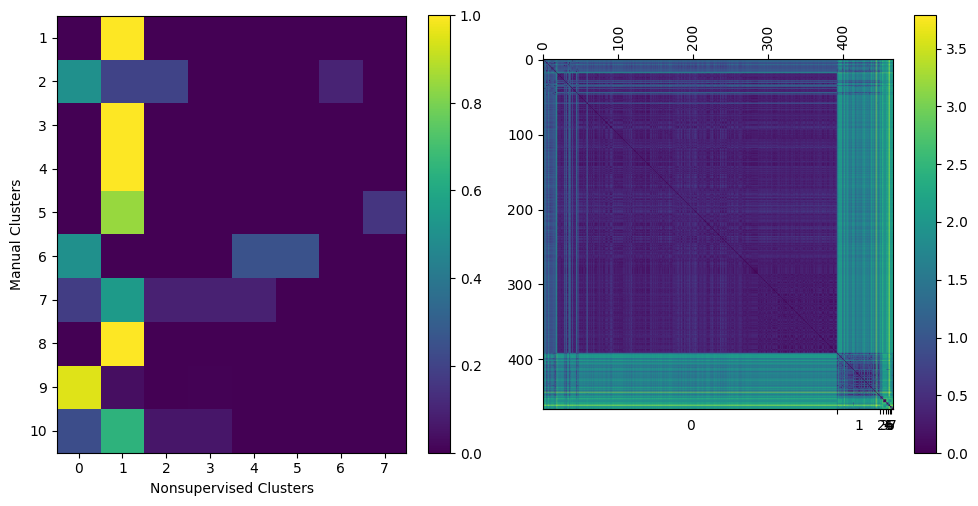

In [29]:
# Observe Manual Cluster VS Spectral Cluster Labels Interactively
 
print("Current Number of Clusters: ", clst_num )
spec_clust_proj = spec_cluster_labels[clst_num]
print(spec_clust_proj.keys())
print(len(spec_clust_proj))
clst_num += 1                                                                   # Make the Cell Interactive

size_ordered_spect_labels = list(spec_clust_proj.keys())
lst_manual_labels = [ [ spec_clust_proj[idx]["manual_label"].count(manual_label) / np.sum( np.array( [proj["manual_label"].count(manual_label) for proj in spec_clust_proj.values() ] ))
                      for manual_label in list( range( 1, 11 ) ) ]  
                    for idx in size_ordered_spect_labels ]

print( np.array(lst_manual_labels).shape)
labels_array = np.array(lst_manual_labels).T

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

im0 = ax[0].imshow(labels_array)
plt.colorbar(im0, ax=ax[0])
ax[0].set_ylabel("Manual Clusters")
ax[0].set_xlabel("Nonsupervised Clusters")
ax[0].set_xticks(list(range(len(spec_clust_proj))), labels = size_ordered_spect_labels)
ax[0].set_yticks(list(range(len(manual_cluster_dict.keys()))), labels=list(manual_cluster_dict.keys()))

new_order = [idx for clust in spec_clust_proj.values() for idx in clust["idxs"]]

new_coord_x, new_coord_y = list(zip(*[(x, y) for x in new_order for y in new_order]))
new_coord_x, new_coord_y = np.array(new_coord_x), np.array(new_coord_y)
reorder_rmsd_mat = ca_rmsd_matrix[new_coord_x, new_coord_y].reshape(ca_rmsd_matrix.shape[0], ca_rmsd_matrix.shape[0])

im1 = ax[1].imshow(reorder_rmsd_mat)
cumul_count = list(np.cumsum([len(clust["idxs"]) for clust in list(spec_clust_proj.values())]) )# list()
cumul_count = [np.float64(0)] + cumul_count
inbetween_vals = [ np.mean( [cumul_count[idx], cumul_count[idx+1]])   for idx in range(len(cumul_count)-1)]
all_ticks = [  item for list in  [ [btween, cumul] for btween, cumul in zip(inbetween_vals, cumul_count[1:] ) ] for item in list ]
all_labels = [  item for list in  [ [label, cumul] for label, cumul in zip(size_ordered_spect_labels, cumul_count[1:] ) ] for item in list ]
format_dual_axis(ax[1], all_ticks, all_labels)
plt.colorbar(im1, ax=ax[1])

plt.tight_layout()
plt.show()


<img src="../../../../images/clusters/clusters.png" width = 20%>


(5, 10)


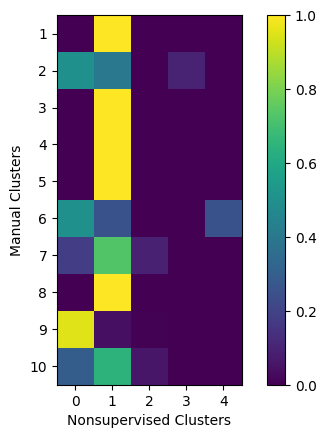

(467, 467)


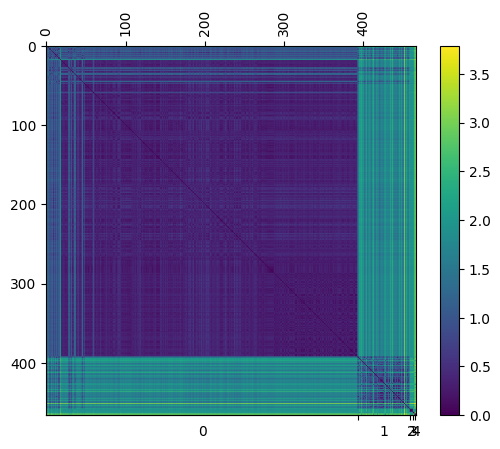

In [ ]:
# Plot in Separate View

lst_manual_labels = [ [ spec_clust_proj[idx]["manual_label"].count(manual_label) / np.sum( np.array( [proj["manual_label"].count(manual_label) for proj in spec_clust_proj.values() ] ))
                      for manual_label in list( range( 1, 11 ) ) ]  
                    for idx in range(len(spec_clust_proj)) ]

print( np.array(lst_manual_labels).shape)
labels_array = np.array(lst_manual_labels).T

plt.figure()
plt.imshow(labels_array)
plt.colorbar()
plt.ylabel("Manual Clusters")
plt.xlabel("Nonsupervised Clusters")
plt.xticks(list(range( len(spec_clust_proj))))
plt.yticks( list( range( len( manual_cluster_dict.keys()))), labels = list( manual_cluster_dict.keys()) )
plt.show()
# manual_labels = list( range( 1, 11 ) )

new_order = [ idx for clust in spec_clust_proj.values() for idx in clust["idxs"] ]

new_coord_x, new_coord_y = list(zip( *[ (x, y) for x in new_order for y in new_order] ))
new_coord_x, new_coord_y = np.array(new_coord_x), np.array(new_coord_y)
reorder_rmsd_mat = ca_rmsd_matrix[new_coord_x, new_coord_y].reshape( ca_rmsd_matrix.shape[0], ca_rmsd_matrix.shape[0])
print(reorder_rmsd_mat.shape)
plt.figure()
plt.imshow( reorder_rmsd_mat)
ax = plt.gca()
cumul_count = list( np.cumsum( [ len(clust["idxs"]) for clust in list(spec_clust_proj.values())]  ) )
cumul_count = [np.float64(0)] + cumul_count
inbetween_vals = [ np.mean( [cumul_count[idx], cumul_count[idx+1]])   for idx in range(len(cumul_count)-1)]
all_ticks = [  item for list in  [ [btween, cumul] for btween, cumul in zip(inbetween_vals, cumul_count[1:] ) ] for item in list ]
all_labels = [  item for list in  [ [label, cumul] for label, cumul in zip(size_ordered_spect_labels, cumul_count[1:] ) ] for item in list ]
im = ax.imshow(reorder_rmsd_mat)
format_dual_axis(ax, all_ticks,all_labels )
plt.colorbar()
# plt.savefig( rootdir.joinpath("images/rmsd/reordered_rmsd_matrix.png"), dpi = 1000, bbox_inches = "tight" )
plt.show()


### Extract Dataset names For a specific cluster name

In [23]:
print( [ item for item in spec_cluster_labels[5][0]["datasets"] ])

['A0365a', 'A0310a', 'A0514a', 'A1169a', 'A0884a', 'A0351a', 'A0387a', 'A0875a', 'A0528a', 'A0487a', 'A0911a', 'A0237a', 'A0437a', 'A0926a', 'A0207a', 'A0450a', 'A0554a', 'A1080a', 'A0812a', 'A7465a', 'A7501b', 'A3550b', 'A3181b', 'A7510b', 'A5836a', 'A6838a', 'A7491a', 'A5381a', 'A0528b', 'A0412a', 'A7459a', 'A1105a', 'A0863a', 'A7014a', 'A5721b', 'A0875b', 'A0351b', 'A0379a', 'A7038a', 'A7475a', 'A0514b', 'A7515a', 'A7533a', 'A3977b', 'A7461a', 'A0554b', 'A0926a', 'A3054a', 'A3186a', 'A3188a', 'A3189a', 'A3191a', 'A3193a', 'A3194a', 'A3207a', 'A3208a', 'A3210a', 'A3218a', 'A3221a', 'A3222a', 'A3223a', 'A3225a', 'A3229a', 'A3417a', 'A3450a', 'A3480a', 'A3483a', 'A3485a', 'A3488a', 'A3489a', 'A3510a', 'A3546a', 'A3548a', 'A3550a', 'A3575a', 'A3581a', 'A3585a', 'A3587a', 'A3606a', 'A3612a', 'A3618a', 'A3665a', 'A3849a', 'A3868a', 'A3883a', 'A3890a', 'A3901a', 'A3908a', 'A3914a', 'A3920a', 'A3936a', 'A3937a', 'A3938a', 'A3939a', 'A3940a', 'A3942a', 'A3944a', 'A3954a', 'A3968a', 'A3975a',